In [ ]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ML-CaseStudy2-Dataset.csv to ML-CaseStudy2-Dataset.csv


In [ ]:
#Read exel file
df = pd.read_csv('ML-CaseStudy2-Dataset.csv')
# Display first  rows
df.head()

,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
0,11de2b9e-2148-4a1e-951b-1323d8f5f941,Austin Rodriguez,59.0,36,25860.0,11,13,6.37,sales,Pune,26.50,1
1,816703b6-7f5c-4511-8bf3-ace06d28333c,Stephanie Salazar,31.0,4,69131.0,11,8,6.86,IT,Mumbai,43.23,1
2,d10e1435-380e-4727-bab0-d1db39ea5e9e,Mrs. Jaclyn Chavez,22.0,0,87955.0,9,2,2.64,Human Resource,Mumbai,43.28,1
3,d8456859-9280-4bb0-a772-78952813e838,Susan Quinn,42.0,14,131970.0,13,12,9.76,sales,Chennai,77.60,1
4,791f7234-a526-4b85-adaa-70b4b01cbad8,Matthew Nelson,35.0,13,92435.0,10,4,6.33,sales,Hyderabad,58.22,0


In [ ]:
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            5050 non-null   object 
 1   Employee_Name          5050 non-null   object 
 2   Age                    4950 non-null   float64
 3   Years_of_Experience    5050 non-null   int64  
 4   Monthly_Salary         4949 non-null   float64
 5   Working_Hours_Per_Day  5050 non-null   int64  
 6   Projects_Handled       5050 non-null   int64  
 7   Job_Satisfaction       4949 non-null   float64
 8   Department             5050 non-null   object 
 9   City                   5050 non-null   object 
 10  Performance_Score      5050 non-null   float64
 11  Attrition_Flag         5050 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 473.6+ KB
None

Summary Statistics:
               Age  Years_of_Experience  Monthly_Salary  \
c

In [ ]:
# -------------------------------------------------
# STEP 3: DATA UNDERSTANDING
# -------------------------------------------------

# Shape of dataset
print("Dataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Information about dataset
print("\nDataset Information:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(5050, 12)

Column Names:
Index(['Employee_ID', 'Employee_Name', 'Age', 'Years_of_Experience',
       'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled',
       'Job_Satisfaction', 'Department', 'City', 'Performance_Score',
       'Attrition_Flag'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            5050 non-null   object 
 1   Employee_Name          5050 non-null   object 
 2   Age                    4950 non-null   float64
 3   Years_of_Experience    5050 non-null   int64  
 4   Monthly_Salary         4949 non-null   float64
 5   Working_Hours_Per_Day  5050 non-null   int64  
 6   Projects_Handled       5050 non-null   int64  
 7   Job_Satisfaction       4949 non-null   float64
 8   Department             5050 non-null   object 
 

In [ ]:
# Fill numerical missing values with mean
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical missing values with mode
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify again
print(df.isnull().sum())

Employee_ID              0
Employee_Name            0
Age                      0
Years_of_Experience      0
Monthly_Salary           0
Working_Hours_Per_Day    0
Projects_Handled         0
Job_Satisfaction         0
Department               0
City                     0
Performance_Score        0
Attrition_Flag           0
dtype: int64


In [ ]:
# --------------------------------------------
# STEP 5: ENCODE CATEGORICAL VARIABLES
# --------------------------------------------

label_encoder = LabelEncoder()
df['Employee_ID'] = label_encoder.fit_transform(df['Employee_ID'])
df['Employee_Name'] = label_encoder.fit_transform(df['Employee_Name'])
df['City'] = label_encoder.fit_transform(df['City'])
df['Department'] = label_encoder.fit_transform(df['Department'])
df.head()

,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
0,387,462,59.0,36,25860.0,11,13,6.37,8,6,26.50,1
1,2502,4350,31.0,4,69131.0,11,8,6.86,4,5,43.23,1
2,4071,3577,22.0,0,87955.0,9,2,2.64,3,5,43.28,1
3,4204,4440,42.0,14,131970.0,13,12,9.76,8,2,77.60,1
4,2350,3233,35.0,13,92435.0,10,4,6.33,8,4,58.22,0


Ridge Regression Objective

Objective:
To predict Performance_Score while reducing the effect of multicollinearity and improving model stability using regularization

In [ ]:
# ================================================
# STEP 6: DEFINE X AND Y
# ================================================

# Drop target + id column from features
X = df.drop(['Performance_Score'], axis=1)

y = df['Performance_Score']

print("Independent Variables:")
print(X.head())
print("\nX shape:", X.shape)

print("\nTarget Variable:")
print(y.head())
print("\ny shape:", y.shape)

Independent Variables:
   Employee_ID  Employee_Name   Age  Years_of_Experience  Monthly_Salary  \
0          387            462  59.0                   36         25860.0   
1         2502           4350  31.0                    4         69131.0   
2         4071           3577  22.0                    0         87955.0   
3         4204           4440  42.0                   14        131970.0   
4         2350           3233  35.0                   13         92435.0   

   Working_Hours_Per_Day  Projects_Handled  Job_Satisfaction  Department  \
0                     11                13              6.37           8   
1                     11                 8              6.86           4   
2                      9                 2              2.64           3   
3                     13                12              9.76           8   
4                     10                 4              6.33           8   

   City  Attrition_Flag  
0     6               1  
1     5    

In [ ]:
# -------------------------------------------------
# STEP 7: TRAIN TEST SPLIT
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:")
print(X_train.shape)

print("Testing Data Shape:")
print(X_test.shape)

Training Data Shape:
(4040, 11)
Testing Data Shape:
(1010, 11)


In [ ]:

# STEP 8: FEATURE SCALING
# -------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
# STEP 9: FIND BEST ALPHA
# -------------------------------------------------

alpha_values = [0.01, 0.1, 1, 10, 50, 100]

ridge_cv = RidgeCV(alphas=alpha_values)

ridge_cv.fit(X_train_scaled, y_train)

best_alpha = ridge_cv.alpha_

print("Best Alpha Value:")
print(best_alpha)

Best Alpha Value:
100.0


In [ ]:
# STEP 10: TRAIN RIDGE REGRESSION MODEL
# -------------------------------------------------

ridge_model = Ridge(alpha=best_alpha)

ridge_model.fit(X_train_scaled, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
# STEP 11: PREDICTION
# -------------------------------------------------

y_pred = ridge_model.predict(X_test_scaled)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[37.55997242 56.5406513  50.93158126 64.18993446 47.71966633 68.25123428
 49.20026851 36.08630442 53.37417375 43.01929072]


In [ ]:
# STEP 12: MODEL EVALUATION
# ================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("---------------------------")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 Score : {r2:.4f}")

Model Evaluation Metrics
---------------------------
MAE  : 11.99
MSE  : 251.65
RMSE : 15.86
R2 Score : 0.3305


In [ ]:
# STEP 13: COEFFICIENT ANALYSIS
# ================================================

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_model.coef_
})

print(coefficients)

                  Feature  Coefficient
0             Employee_ID    -0.163424
1           Employee_Name     0.197689
2                     Age     0.837619
3     Years_of_Experience     2.185806
4          Monthly_Salary     9.558870
5   Working_Hours_Per_Day     1.619717
6        Projects_Handled    -0.251816
7        Job_Satisfaction     2.138632
8              Department     0.445005
9                    City     0.108486
10         Attrition_Flag    -4.197969


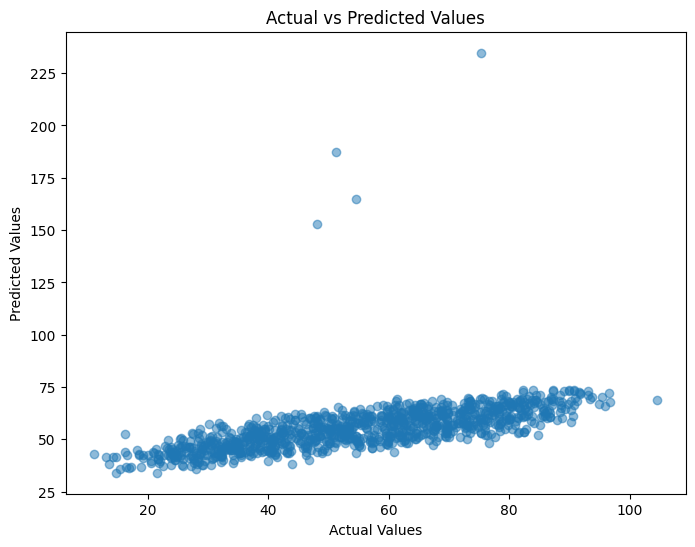

In [ ]:
# STEP 14: ACTUAL VS PREDICTED GRAPH
# ================================================


plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

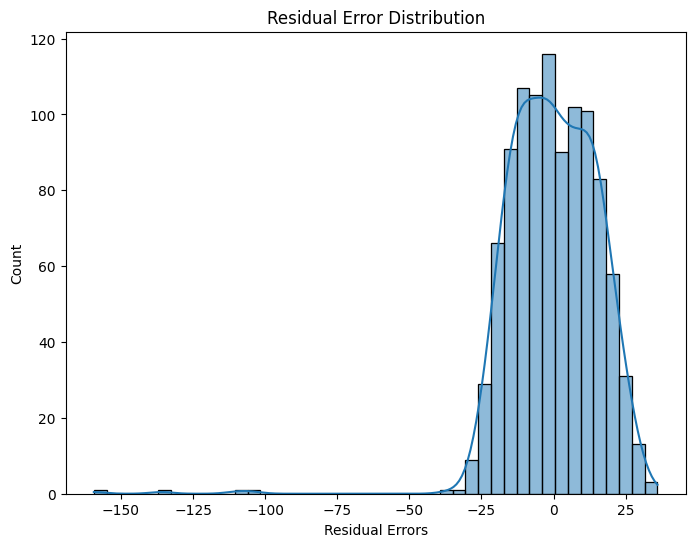

In [ ]:

# STEP 15: RESIDUAL ERROR PLOT
# ================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Error Distribution")

plt.xlabel("Residual Errors")

plt.show()

In [ ]:
# STEP 16: ACTUAL VS PREDICTED TABLE
# ================================================

comparison = pd.DataFrame({
    'Actual_Value': y_test.values,
    'Predicted_Value': y_pred
})


print(comparison.head(20))

    Actual_Value  Predicted_Value
0          29.02        37.559972
1          67.54        56.540651
2          57.12        50.931581
3          63.41        64.189934
4          37.96        47.719666
5          91.32        68.251234
6          28.30        49.200269
7          16.98        36.086304
8          42.53        53.374174
9          28.77        43.019291
10         81.46        52.841785
11         78.51        57.202700
12         50.16        55.067338
13         38.03        60.229967
14         56.25        55.226263
15         18.95        36.732524
16         73.35        56.624678
17         36.79        57.190941
18         55.87        58.111595
19         78.19        64.650814


**Conclusion **

Ridge Regression was applied to predict employee Performance_Score using employee-related features such as Age, Years_of_Experience, Monthly_Salary, Working_Hours_Per_Day, Projects_Handled, and Job_Satisfaction. The model used an optimal alpha value of 100.0 to reduce multicollinearity and improve prediction stability through regularization.

The model achieved a Mean Absolute Error (MAE) of 11.99, Mean Squared Error (MSE) of 251.65, Root Mean Squared Error (RMSE) of 15.86, and an R² Score of 0.330. The R² value indicates that the model explains approximately 33% of the variation in employee performance scores.

Although Ridge Regression provided stable predictions and controlled overfitting, the moderate R² score suggests that the model has limited predictive power and that prediction errors still exist between actual and predicted values

Overall, Ridge Regression proved to be an effective regularized regression technique for employee performance prediction.